In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset size:", len(dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.88MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.94MB/s]

Dataset size: 60000


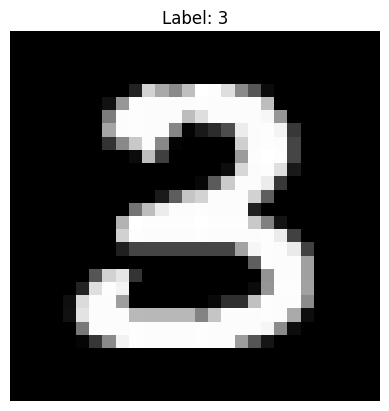

In [3]:
import matplotlib.pyplot as plt

images, labels = next(iter(dataloader))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [4]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 1, 28, 28)

In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
generator = Generator().to(device)

print(generator)

Device: cuda
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


In [6]:
noise = torch.randn(1, 100).to(device)

fake_image = generator(noise)

print("Fake image shape:", fake_image.shape)

Fake image shape: torch.Size([1, 1, 28, 28])


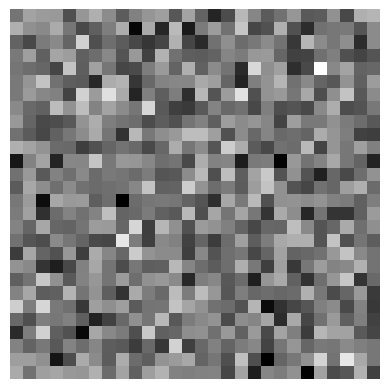

In [7]:
plt.imshow(fake_image[0].detach().cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.model(x)

In [9]:
discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [10]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [11]:
noise_dim = 100
num_epochs = 20

In [12]:
num_epochs = 20
noise_dim = 100

g_losses = []
d_losses = []

In [13]:
for epoch in range(num_epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # -------------------------
        # 1. Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(real_images)
        d_loss_real = criterion(real_output, real_labels)

        # Fake images
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        # Total Discriminator loss
        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # 2. Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)

        output = discriminator(fake_images)

        g_loss = criterion(output, real_labels)

        g_loss.backward()
        optimizer_G.step()

    # Save losses
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/20] D Loss: 0.7202 G Loss: 3.1522
Epoch [2/20] D Loss: 0.5998 G Loss: 2.3875
Epoch [3/20] D Loss: 0.0977 G Loss: 4.3816
Epoch [4/20] D Loss: 0.3802 G Loss: 2.1017
Epoch [5/20] D Loss: 0.6263 G Loss: 3.6720
Epoch [6/20] D Loss: 0.1364 G Loss: 3.5053
Epoch [7/20] D Loss: 0.1849 G Loss: 7.8734
Epoch [8/20] D Loss: 0.0001 G Loss: 9.6617
Epoch [9/20] D Loss: 0.0001 G Loss: 10.8437
Epoch [10/20] D Loss: 0.0000 G Loss: 10.1732
Epoch [11/20] D Loss: 0.0006 G Loss: 7.6786
Epoch [12/20] D Loss: 0.0031 G Loss: 7.0759
Epoch [13/20] D Loss: 0.0002 G Loss: 8.5955
Epoch [14/20] D Loss: 0.0000 G Loss: 9.9816
Epoch [15/20] D Loss: 0.0000 G Loss: 11.5071
Epoch [16/20] D Loss: 0.0000 G Loss: 11.1094
Epoch [17/20] D Loss: 0.0000 G Loss: 31.4940
Epoch [18/20] D Loss: 0.0000 G Loss: 10.8908
Epoch [19/20] D Loss: 0.0000 G Loss: 11.6945
Epoch [20/20] D Loss: 0.0000 G Loss: 12.7649


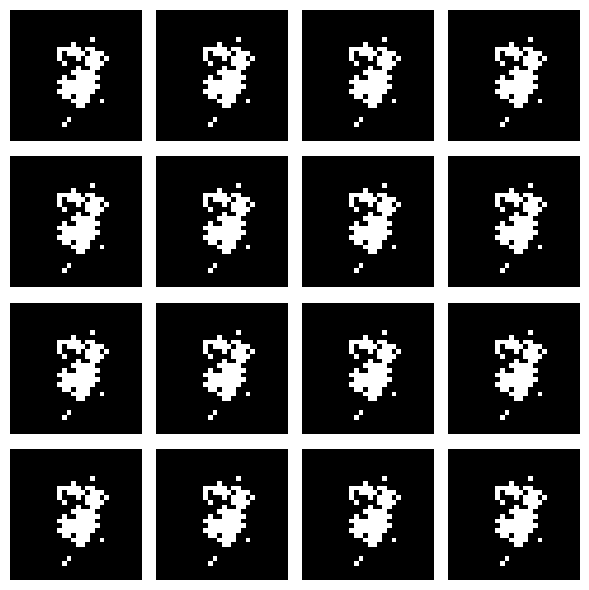

In [14]:
import matplotlib.pyplot as plt
import torch

generator.eval()

noise = torch.randn(16, noise_dim).to(device)

with torch.no_grad():
    generated_images = generator(noise)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


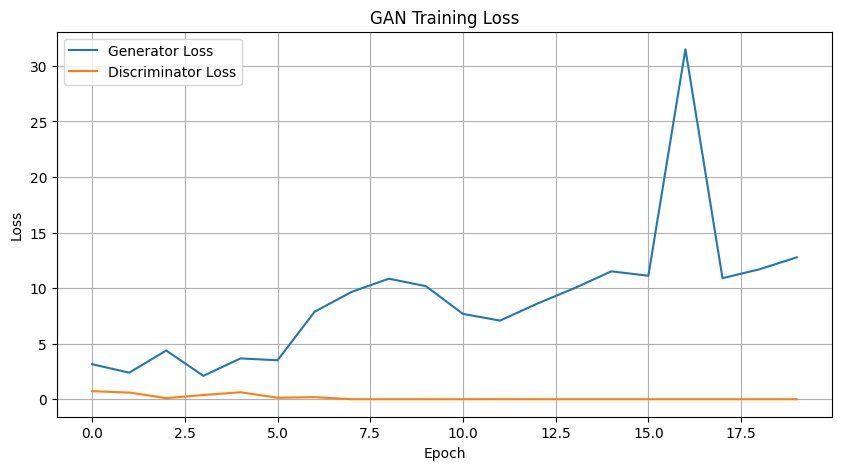

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid()

plt.show()

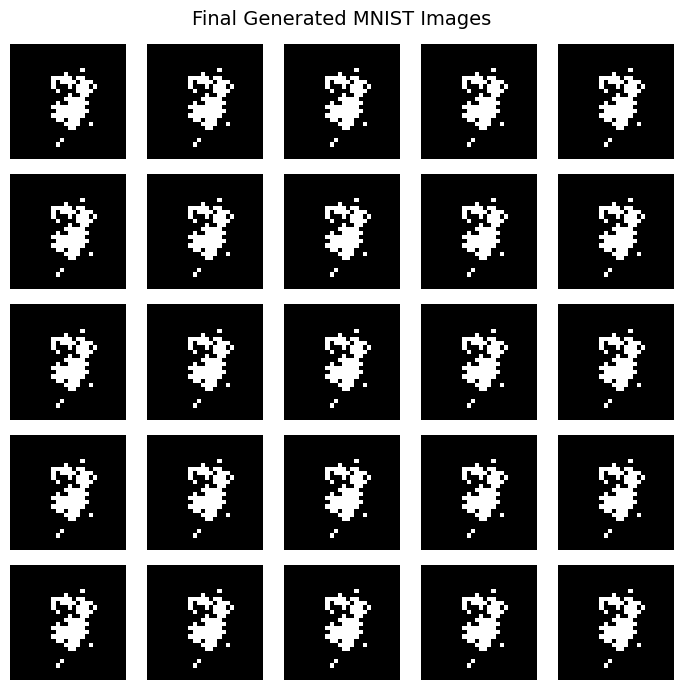

In [16]:
generator.eval()

noise = torch.randn(25, noise_dim).to(device)

with torch.no_grad():
    generated_images = generator(noise)

fig, axes = plt.subplots(5, 5, figsize=(7, 7))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("Final Generated MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

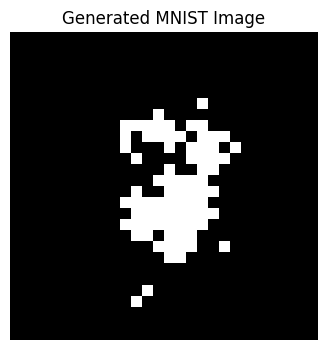

In [17]:
generator.eval()

noise = torch.randn(1, noise_dim).to(device)

with torch.no_grad():
    generated_image = generator(noise)

plt.figure(figsize=(4,4))
plt.imshow(
    generated_image[0].cpu().squeeze(),
    cmap="gray"
)
plt.axis("off")
plt.title("Generated MNIST Image")
plt.show()

# Final Results

The GAN was successfully implemented using PyTorch and trained on the MNIST dataset.

* The **Generator** learned to create synthetic images from random noise.
* The **Discriminator** learned to distinguish between real MNIST images and generated images.
* Both networks were independently updated within the same training loop.
* Generated images were visualized using a 5×5 image grid.
* Generator and Discriminator losses were recorded and visualized during training.

## Conclusion

GAN training is an adversarial process where the Generator tries to create realistic images while the Discriminator tries to identify fake images. During training, both networks compete and learn from each other. In this experiment, the Generator produced synthetic images resembling handwritten MNIST digits.

## Training Observation

The Discriminator became very strong during later epochs, resulting in a very low Discriminator loss and a high Generator loss. This shows that GAN training can become unstable when one network becomes significantly stronger than the other. Techniques such as WGAN, gradient penalty, and improved network architectures can help stabilize training.
